In [ ]:
#conexão com o banco de dados
import mysql.connector as sql
import pandas as pd

db_connection = sql.connect(host="localhost",user='root',password="12345",database="statlog")
db_cursor = db_connection.cursor()

db_cursor.execute("SELECT * FROM germancredit")

table_rows = db_cursor.fetchall()
df = pd.DataFrame(table_rows)
table_columns = db_cursor.column_names
df.columns = table_columns  # Define os nomes das colunas no DataFrame

# Filtrar apenas clientes maiores de idade (idade >= 18)
df_filtrado = df[df['alter'] >= 18]  # Substitua 'alter' pelo nome correto da coluna de idade
df = df_filtrado
print(df.columns)  # Exibe os nomes das colunas do DataFrame filtrado

Index(['id', 'laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont',
       'beszeit', 'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter',
       'weitkred', 'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb',
       'kredit'],
      dtype='object')


In [5]:
#Análise exploratória e limpeza de dados
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        1000 non-null   int64
 1   laufkont  1000 non-null   int64
 2   laufzeit  1000 non-null   int64
 3   moral     1000 non-null   int64
 4   verw      1000 non-null   int64
 5   hoehe     1000 non-null   int64
 6   sparkont  1000 non-null   int64
 7   beszeit   1000 non-null   int64
 8   rate      1000 non-null   int64
 9   famges    1000 non-null   int64
 10  buerge    1000 non-null   int64
 11  wohnzeit  1000 non-null   int64
 12  verm      1000 non-null   int64
 13  alter     1000 non-null   int64
 14  weitkred  1000 non-null   int64
 15  wohn      1000 non-null   int64
 16  bishkred  1000 non-null   int64
 17  beruf     1000 non-null   int64
 18  pers      1000 non-null   int64
 19  telef     1000 non-null   int64
 20  gastarb   1000 non-null   int64
 21  kredit    1000 non-null   i

In [6]:
#renomeando as colunas
df.columns = table_columns
df.drop('id', axis=1, inplace=True)
print(df.columns)


Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')


In [7]:
#Escolha das features
X = df.drop("kredit", axis=1)  # Todas as colunas menos a saída
y = df["kredit"] #saída


In [8]:
#Divisão dos dados em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # 80% treino, 20% teste
)


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

def encontrar_melhor_profundidade(X, y, profundidades=range(1, 21)):
    scores = []

    for d in profundidades:
        modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
        score = cross_val_score(modelo, X, y, cv=5).mean()
        scores.append(score)
        print(f"Profundidade {d} → Acurácia média: {score:.4f}")

    melhor_indice = scores.index(max(scores))
    melhor_profundidade = profundidades[melhor_indice]

    # Gráfico opcional
    plt.figure(figsize=(10, 5))
    plt.plot(profundidades, scores, marker='o', color='orange')
    plt.title("Acurácia média vs. Profundidade da Árvore")
    plt.xlabel("max_depth")
    plt.ylabel("Acurácia média (cross-validation)")
    plt.grid(True)
    plt.xticks(profundidades)
    plt.show()

    print(f"\n✅ Melhor profundidade encontrada: {melhor_profundidade} com acurácia média de {scores[melhor_indice]:.4f}")
    return melhor_profundidade


Profundidade 1 → Acurácia média: 0.7000
Profundidade 2 → Acurácia média: 0.7020
Profundidade 3 → Acurácia média: 0.7100
Profundidade 4 → Acurácia média: 0.7080
Profundidade 5 → Acurácia média: 0.7030
Profundidade 6 → Acurácia média: 0.6830
Profundidade 7 → Acurácia média: 0.6770
Profundidade 8 → Acurácia média: 0.6860
Profundidade 9 → Acurácia média: 0.6930
Profundidade 10 → Acurácia média: 0.6730
Profundidade 11 → Acurácia média: 0.6690
Profundidade 12 → Acurácia média: 0.6580
Profundidade 13 → Acurácia média: 0.6730
Profundidade 14 → Acurácia média: 0.6640
Profundidade 15 → Acurácia média: 0.6770
Profundidade 16 → Acurácia média: 0.6760
Profundidade 17 → Acurácia média: 0.6740
Profundidade 18 → Acurácia média: 0.6700
Profundidade 19 → Acurácia média: 0.6700
Profundidade 20 → Acurácia média: 0.6700


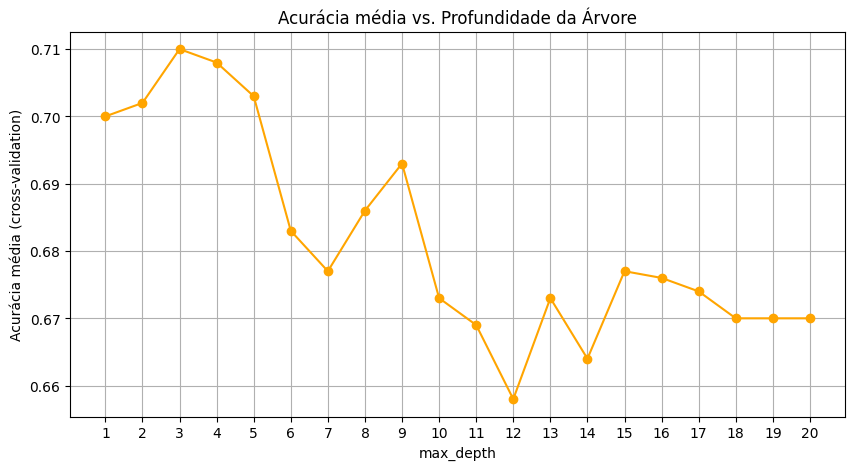


✅ Melhor profundidade encontrada: 3 com acurácia média de 0.7100


In [10]:
melhor_depth = encontrar_melhor_profundidade(X, y)


In [11]:
#treinando o modelo com base na melhor profundidade encontrada
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=3,        # Limita a profundidade da árvore (para evitar overfitting)
    criterion="gini",   # Ou 'entropy'
    random_state=42
)

modelo.fit(X_train, y_train)  # Treina o modelo com os dados de treino


DecisionTreeClassifier(max_depth=3, random_state=42)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 26  36]
 [ 26 112]]
              precision    recall  f1-score   support

           0       0.50      0.42      0.46        62
           1       0.76      0.81      0.78       138

    accuracy                           0.69       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.68      0.69      0.68       200



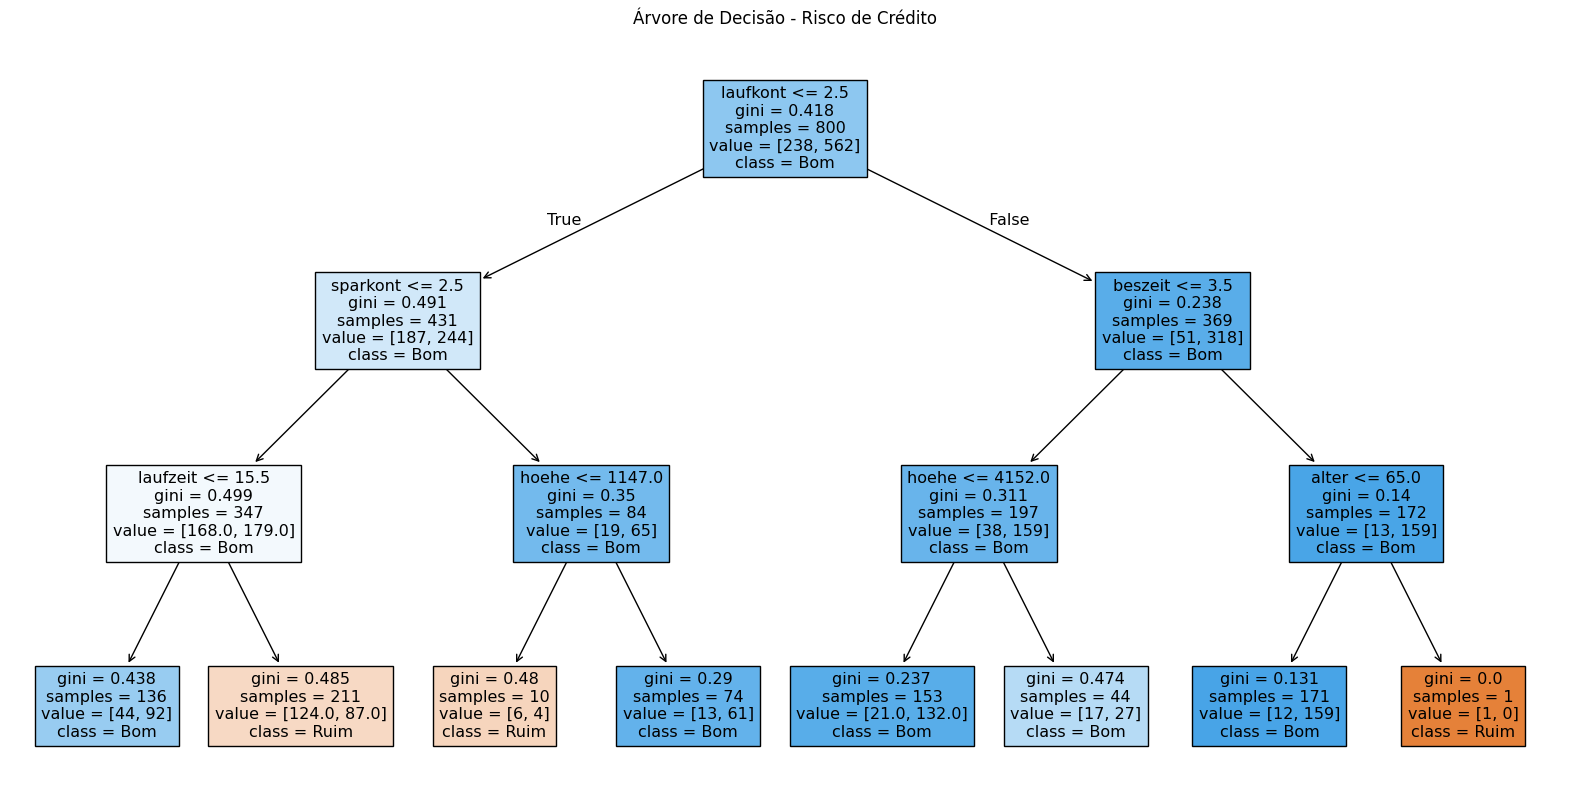

In [13]:
#Visualização dos dados
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(modelo, feature_names=X.columns, class_names=["Ruim", "Bom"], filled=True)
plt.title("Árvore de Decisão - Risco de Crédito")
plt.show()


In [15]:
# Mapeamento para validação e tratamento das entradas
dicionario_variaveis = {
    "laufkont": {1: "Sem conta corrente", 2: "Saldo menor que 0 DM", 3: "Saldo entre 0 e 200 DM", 4: "Saldo maior ou igual a 200 DM / salário estável"},
    "moral": {0: "Atraso anterior", 1: "Conta crítica / outros créditos", 2: "Nenhum crédito / todos pagos", 3: "Créditos pagos corretamente até agora", 4: "Todos os créditos neste banco pagos corretamente"},
    "verw": {0: "Outros", 1: "Carro novo", 2: "Carro usado", 3: "Móveis / Equipamentos", 4: "Rádio / TV", 5: "Eletrodomésticos", 6: "Reparos", 7: "Educação", 8: "Férias", 9: "Reciclagem profissional", 10: "Negócios"},
    "sparkont": {1: "Desconhecido / Nenhuma", 2: "< 100 DM", 3: "100–499 DM", 4: "500–999 DM", 5: ">= 1000 DM"},
    "beszeit": {1: "Desempregado", 2: "< 1 ano", 3: "1 a < 4 anos", 4: "4 a < 7 anos", 5: ">= 7 anos"},
    "rate": {1: ">= 35%", 2: "25% a < 35%", 3: "20% a < 25%", 4: "< 20%"},
    "famges": {1: "Homem divorciado / separado", 2: "Mulher não solteira ou homem solteiro", 3: "Homem casado / viúvo", 4: "Mulher solteira"},
    "buerge": {1: "Nenhum", 2: "Co-requerente", 3: "Fiador"},
    "wohnzeit": {1: "< 1 ano", 2: "1 a < 4 anos", 3: "4 a < 7 anos", 4: ">= 7 anos"},
    "verm": {1: "Nenhuma / desconhecida", 2: "Carro ou outro bem", 3: "Poupança / seguro", 4: "Imóvel"},
    "weitkred": {1: "Banco", 2: "Lojas", 3: "Nenhum"},
    "wohn": {1: "Gratuito", 2: "Alugado", 3: "Próprio"},
    "bishkred": {1: "1 crédito", 2: "2–3 créditos", 3: "4–5 créditos", 4: ">= 6 créditos"},
    "beruf": {1: "Desempregado / não qualificado (estrangeiro)", 2: "Não qualificado - residente", 3: "Empregado qualificado / funcionário", 4: "Gerente / autônomo / altamente qualificado"},
    "pers": {1: "3 ou mais", 2: "0 a 2"},
    "telef": {1: "Não possui", 2: "Sim (em nome do cliente)"},
    "gastarb": {1: "Sim", 2: "Não"}
}
# Função para classificar novos dados com validação e exibição em português
def classificar_novo_cliente_com_tratamento(modelo, colunas, dicionario):
    print("Insira os dados do cliente:")
    novo_cliente = {}
    
    # Tradução dos significados das colunas
    significados_colunas = {
        "laufkont": "Status da Conta Corrente",
        "laufzeit": "Duração do Empréstimo (em meses)",
        "moral": "Histórico de Crédito",
        "verw": "Finalidade do Crédito",
        "hoehe": "Valor do Empréstimo (em DM)",
        "sparkont": "Conta Poupança",
        "beszeit": "Tempo de Emprego",
        "rate": "% da Renda Comprometida",
        "famges": "Estado Civil e Sexo",
        "buerge": "Outros Devedores",
        "wohnzeit": "Tempo de Residência Atual",
        "verm": "Propriedade",
        "alter": "Idade do Cliente",
        "weitkred": "Outros Planos de Parcelamento",
        "wohn": "Habitação",
        "bishkred": "Número de Créditos Existentes",
        "beruf": "Profissão",
        "pers": "Dependentes Financeiros",
        "telef": "Telefone",
        "gastarb": "Trabalhador Estrangeiro"
    }
    
    for coluna in colunas:
        print(f"\n{coluna} → {significados_colunas.get(coluna, 'Descrição não disponível')}:")
        
        if coluna in dicionario:
            # Exibe as opções disponíveis para colunas categóricas
            print("Opções disponíveis:")
            for codigo, significado in dicionario[coluna].items():
                print(f"  {codigo}: {significado}")
            while True:
                try:
                    entrada = int(input(f"Escolha um código válido para {coluna}: ").strip())
                    valor = entrada
                    if valor in dicionario[coluna].keys():  # Valida se o valor está no dicionário
                        novo_cliente[coluna] = valor
                        break
                    else:
                        print("❌ Código inválido. Tente novamente.")
                except ValueError:
                    print("❌ Entrada inválida. Insira um número válido.")
        elif coluna == "alter":  # Validação específica para a idade
            while True:
                try:
                    entrada = input(f"Insira o valor para {coluna} (Idade do Cliente, deve ser >= 18): ").strip()
                    valor = int(entrada)  # Converte para inteiro
                    if valor >= 18:  # Valida se a idade é maior ou igual a 18
                        novo_cliente[coluna] = valor
                        break
                    else:
                        print("❌ Idade inválida. O cliente deve ser maior ou igual a 18 anos.")
                except ValueError:
                    print("❌ Entrada inválida. Insira um número válido.")
        else:
            # Para colunas que não estão no dicionário (valores contínuos, como 'hoehe' e 'laufzeit')
            while True:
                try:
                    entrada = input(f"Insira o valor para {coluna}: ").strip()
                    valor = float(entrada)  # Converte para float
                    novo_cliente[coluna] = valor
                    break
                except ValueError:
                    print("❌ Entrada inválida. Insira um número válido.")
    
    # Converte os dados para um DataFrame
    novo_cliente_df = pd.DataFrame([novo_cliente])
    
    # Faz a previsão
    predicao = modelo.predict(novo_cliente_df)
    
    # Exibe o resultado
    if predicao[0] == 1:
        print("\n✅ O cliente tem risco de crédito: BOM")
    else:
        print("\n❌ O cliente tem risco de crédito: RUIM")

# Chamar a função para classificar um novo cliente
colunas_entrada = X.columns  # Obtém as colunas usadas como entrada no modelo
classificar_novo_cliente_com_tratamento(modelo, colunas_entrada, dicionario_variaveis)

Insira os dados do cliente:

laufkont → Status da Conta Corrente:
Opções disponíveis:
  1: Sem conta corrente
  2: Saldo menor que 0 DM
  3: Saldo entre 0 e 200 DM
  4: Saldo maior ou igual a 200 DM / salário estável



laufzeit → Duração do Empréstimo (em meses):

moral → Histórico de Crédito:
Opções disponíveis:
  0: Atraso anterior
  1: Conta crítica / outros créditos
  2: Nenhum crédito / todos pagos
  3: Créditos pagos corretamente até agora
  4: Todos os créditos neste banco pagos corretamente

verw → Finalidade do Crédito:
Opções disponíveis:
  0: Outros
  1: Carro novo
  2: Carro usado
  3: Móveis / Equipamentos
  4: Rádio / TV
  5: Eletrodomésticos
  6: Reparos
  7: Educação
  8: Férias
  9: Reciclagem profissional
  10: Negócios

hoehe → Valor do Empréstimo (em DM):

sparkont → Conta Poupança:
Opções disponíveis:
  1: Desconhecido / Nenhuma
  2: < 100 DM
  3: 100–499 DM
  4: 500–999 DM
  5: >= 1000 DM

beszeit → Tempo de Emprego:
Opções disponíveis:
  1: Desempregado
  2: < 1 ano
  3: 1 a < 4 anos
  4: 4 a < 7 anos
  5: >= 7 anos

rate → % da Renda Comprometida:
Opções disponíveis:
  1: >= 35%
  2: 25% a < 35%
  3: 20% a < 25%
  4: < 20%

famges → Estado Civil e Sexo:
Opções disponíveis:
  